# 05 — Calibration and Correction

Notebooks 03–04 showed that individual LLM judges diverge from the ensemble consensus.
The divergence is not purely random — it has a linear structure (bias + scaling).
We can exploit this to **calibrate** each judge toward the consensus.

## Goal

Fit one linear corrector per (judge model, metric) pair:

```
corrected_score = a * raw_score + b
```

where `a` (slope) and `b` (intercept) are estimated by least-squares regression of
`raw_score` onto the **ensemble score** (mean of all three judges). After correction,
evaluate whether the post-calibration Cohen's kappa between each judge and the
ensemble exceeds the target threshold (κ ≥ 0.60).


In [1]:
# Setup: path, imports, and data-loading helper
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.agreement.bias import ensemble_scores
from src.agreement.kappa import cohen_kappa
from src.calibration.corrector import LinearCorrector, correction_table
from src.visualisation import calibration_curve

METRICS = ["context_relevance", "groundedness", "answer_relevance"]
KAPPA_TARGET = 0.60


def load_all_scores(root: Path) -> dict:
    """Load judge scores from data/eval/scores_*.json and inject ensemble."""
    result = {}
    eval_dir = root / "data" / "eval"
    for path in sorted(eval_dir.glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        df = pd.DataFrame(records)
        if df["score"].isna().all():
            continue
        model = df["model"].iloc[0]
        model_scores = {}
        for metric in METRICS:
            sub = df[df["metric"] == metric].sort_values("id")
            model_scores[metric] = sub["score"].to_numpy()
        result[model] = model_scores
    if len(result) >= 2:
        result["ensemble"] = ensemble_scores(result)
    return result


print("Setup complete. ROOT =", ROOT)
print(f"Kappa target: {KAPPA_TARGET}")

FIGURES_DIR = ROOT / "outputs" / "figures"
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


Setup complete. ROOT = /workspaces/llm_judge_benchmark
Kappa target: 0.6


In [2]:
# Load scores and verify ensemble
scores = load_all_scores(ROOT)
available_models = [k for k in scores if k != "ensemble"]
has_ensemble = "ensemble" in scores

print(f"Judge models found: {available_models}")
print(f"Ensemble computed: {has_ensemble}")
for model in available_models:
    for metric in METRICS:
        if metric in scores[model]:
            print(f"  {model:20s}  {metric:25s}  n={len(scores[model][metric])}")

if not has_ensemble:
    print("\nWARNING: ensemble not computed — need at least 2 judge score files.")


Judge models found: ['gemma3:4b', 'llama3.1:8b', 'qwen2.5:7b']
Ensemble computed: True
  gemma3:4b             context_relevance          n=50
  gemma3:4b             groundedness               n=50
  gemma3:4b             answer_relevance           n=50
  llama3.1:8b           context_relevance          n=50
  llama3.1:8b           groundedness               n=50
  llama3.1:8b           answer_relevance           n=50
  qwen2.5:7b            context_relevance          n=50
  qwen2.5:7b            groundedness               n=50
  qwen2.5:7b            answer_relevance           n=50


In [3]:
# Fit correctors toward ensemble consensus
fitted_correctors = {}  # {model: {metric: LinearCorrector}}
ct_rows = []

if has_ensemble:
    ensemble_scores_dict = scores["ensemble"]

    for model in available_models:
        fitted_correctors[model] = {}
        for metric in METRICS:
            if metric not in scores[model] or metric not in ensemble_scores_dict:
                continue
            j = scores[model][metric]
            e = ensemble_scores_dict[metric]
            min_len = min(len(j), len(e))
            corrector = LinearCorrector()
            corrector.fit(j[:min_len], e[:min_len])
            fitted_correctors[model][metric] = corrector
            ct_rows.append({"model": model, "metric": metric,
                            "a (slope)": round(corrector.a, 6),
                            "b (intercept)": round(corrector.b, 6)})

    ct_df = pd.DataFrame(ct_rows)
    print("Correction coefficients (corrected = a * raw + b):")
    print(ct_df.to_string(index=False))
else:
    ct_df = pd.DataFrame()
    print("No ensemble — cannot fit correctors.")

if has_ensemble and fitted_correctors:
    coeff_rows = []
    for model in available_models:
        for metric in METRICS:
            if metric in fitted_correctors.get(model, {}):
                corr = fitted_correctors[model][metric]
                coeff_rows.append({"model": model, "metric": metric,
                                   "a": round(corr.a, 6), "b": round(corr.b, 6)})
    coeff_path = RESULTS_DIR / "05_correction_coefficients.json"
    coeff_path.write_text(json.dumps(coeff_rows, indent=2))
    print(f"Saved correction coefficients to {coeff_path}")


Correction coefficients (corrected = a * raw + b):
      model            metric  a (slope)  b (intercept)
  gemma3:4b context_relevance   0.879711       0.038947
  gemma3:4b      groundedness   0.724779       0.193449
  gemma3:4b  answer_relevance   0.671327       0.259270
llama3.1:8b context_relevance   0.704188       0.200098
llama3.1:8b      groundedness   0.813001       0.151648
llama3.1:8b  answer_relevance   0.493552       0.444890
 qwen2.5:7b context_relevance   0.551990       0.431564
 qwen2.5:7b      groundedness   0.789339       0.189190
 qwen2.5:7b  answer_relevance   0.812226       0.152650
Saved correction coefficients to /workspaces/llm_judge_benchmark/outputs/results/05_correction_coefficients.json


In [4]:
# Before/after kappa comparison (judge vs ensemble)
ba_rows = []

if has_ensemble and fitted_correctors:
    ensemble_scores_dict = scores["ensemble"]

    for model in available_models:
        for metric in METRICS:
            if metric not in scores[model] or metric not in ensemble_scores_dict:
                continue
            if metric not in fitted_correctors.get(model, {}):
                continue

            j = scores[model][metric]
            e = ensemble_scores_dict[metric]
            min_len = min(len(j), len(e))

            kappa_before = cohen_kappa(j[:min_len], e[:min_len])

            corrector = fitted_correctors[model][metric]
            j_corrected = corrector.transform(j[:min_len])
            kappa_after = cohen_kappa(j_corrected, e[:min_len])

            ba_rows.append({
                "model": model,
                "metric": metric,
                "kappa_before": round(kappa_before, 4),
                "kappa_after": round(kappa_after, 4),
                "delta": round(kappa_after - kappa_before, 4),
                "above_target": kappa_after >= KAPPA_TARGET,
            })

    ba_df = pd.DataFrame(ba_rows)
    print(f"Before/After Calibration toward ensemble (target kappa >= {KAPPA_TARGET}):")
    print(ba_df.to_string(index=False))
else:
    ba_df = pd.DataFrame()
    print("No correctors fitted — skipping before/after comparison.")

if not ba_df.empty:
    ba_path = RESULTS_DIR / "05_kappa_before_after.json"
    ba_df.to_json(ba_path, orient="records", indent=2)
    print(f"Saved before/after kappa to {ba_path}")


Before/After Calibration toward ensemble (target kappa >= 0.6):
      model            metric  kappa_before  kappa_after  delta  above_target
  gemma3:4b context_relevance        0.6805       0.9042 0.2237          True
  gemma3:4b      groundedness        0.7886       0.7886 0.0000          True
  gemma3:4b  answer_relevance        0.5609       0.6212 0.0604          True
llama3.1:8b context_relevance        0.0775       0.1639 0.0864         False
llama3.1:8b      groundedness        0.5935       0.5935 0.0000         False
llama3.1:8b  answer_relevance        0.3062       0.5930 0.2868         False
 qwen2.5:7b context_relevance        0.4886       0.7452 0.2566          True
 qwen2.5:7b      groundedness        0.8014       0.8026 0.0012          True
 qwen2.5:7b  answer_relevance        0.6032       0.6032 0.0000          True
Saved before/after kappa to /workspaces/llm_judge_benchmark/outputs/results/05_kappa_before_after.json


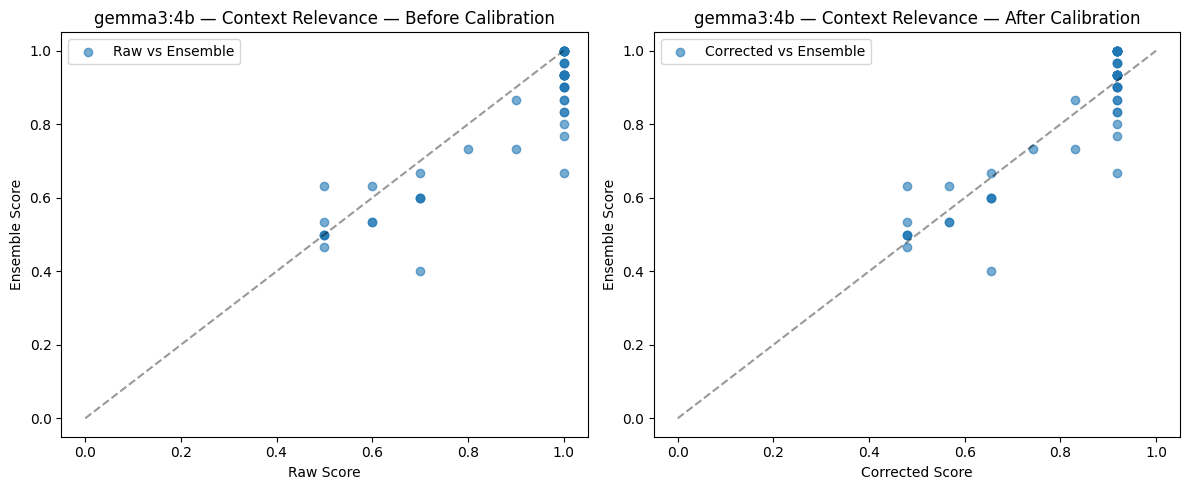

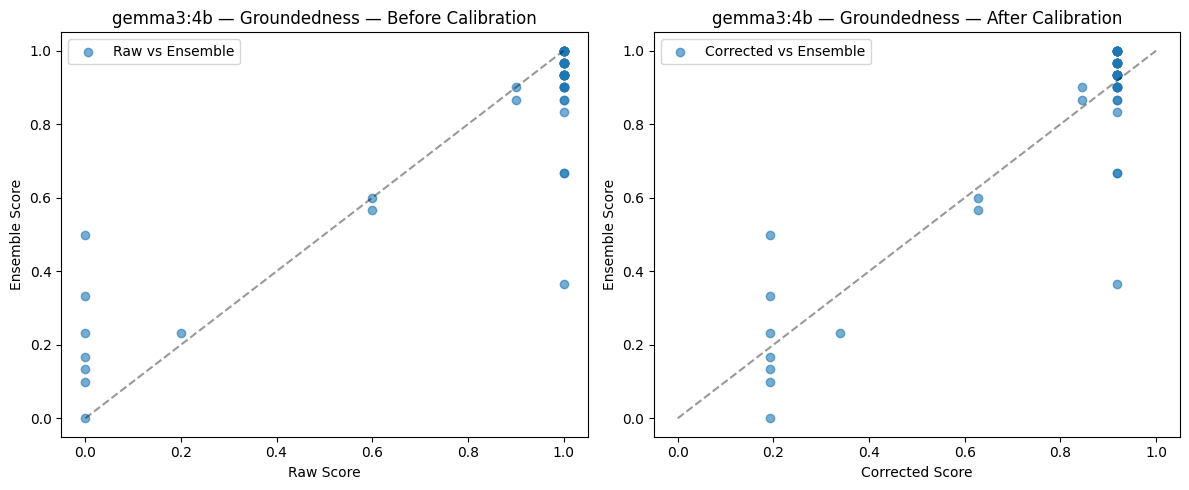

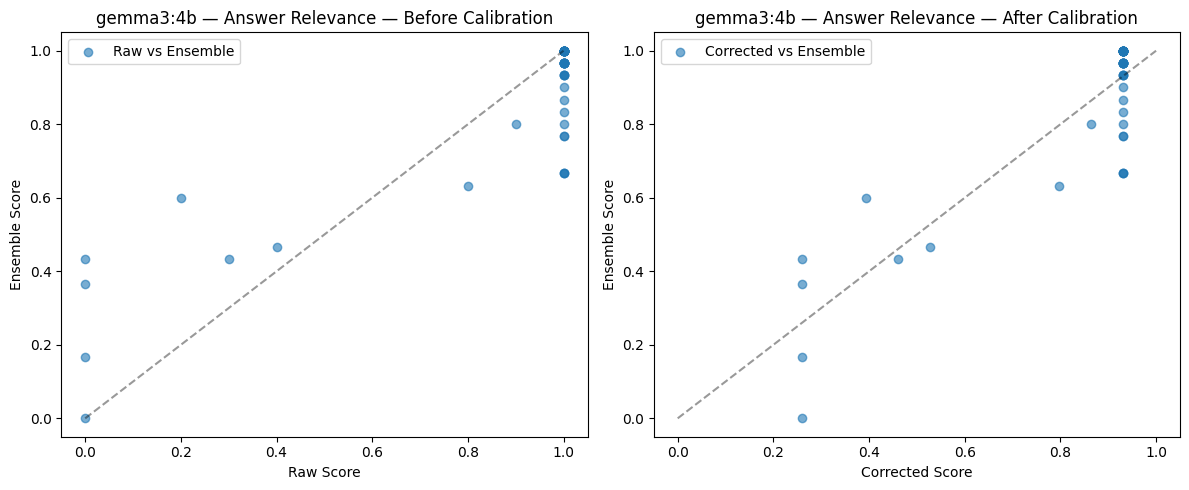

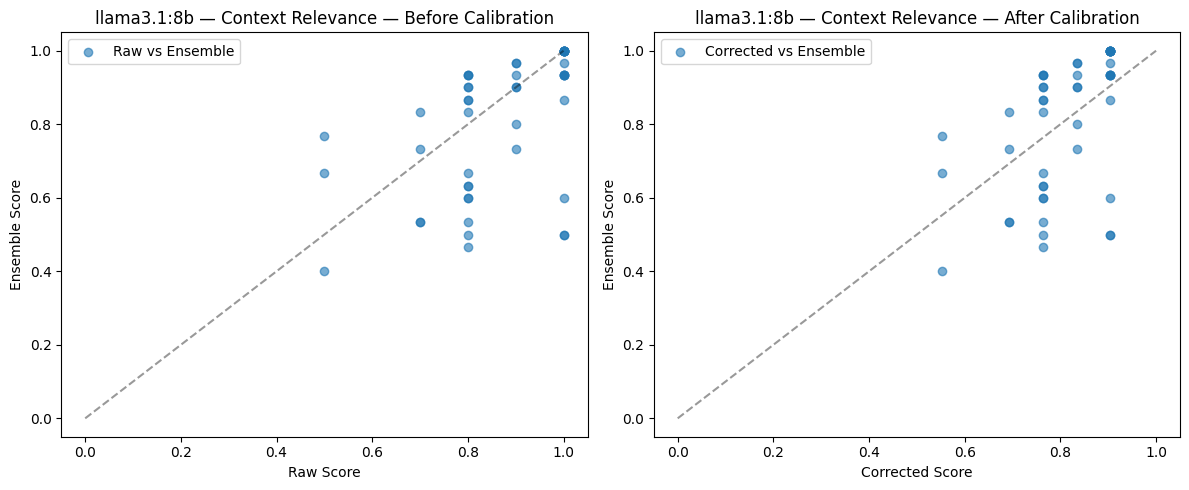

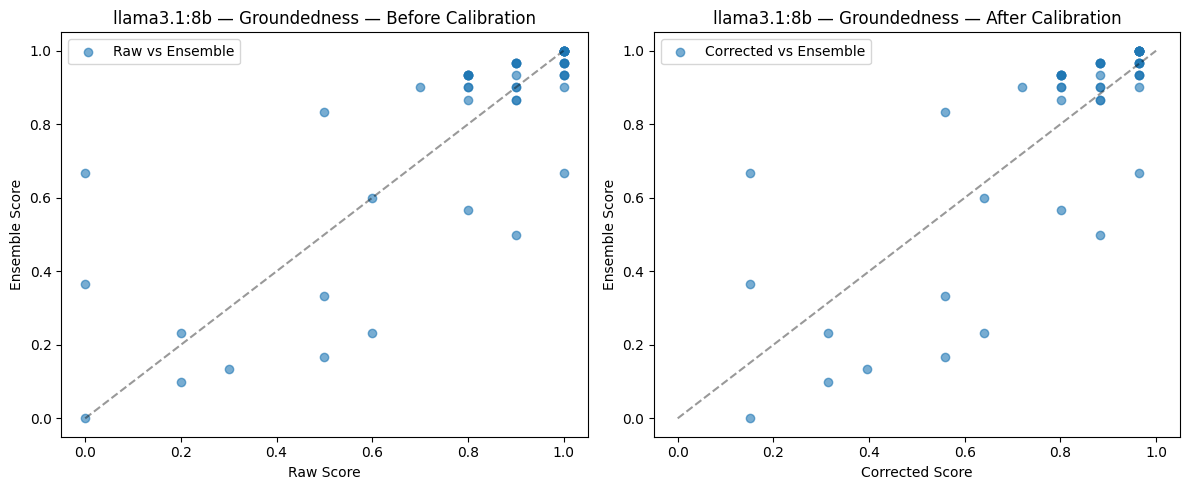

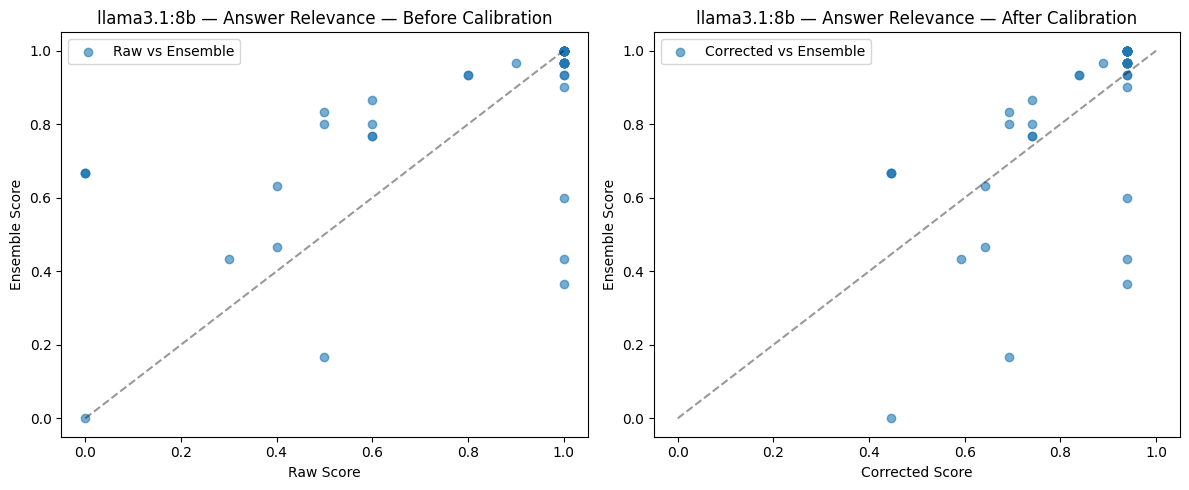

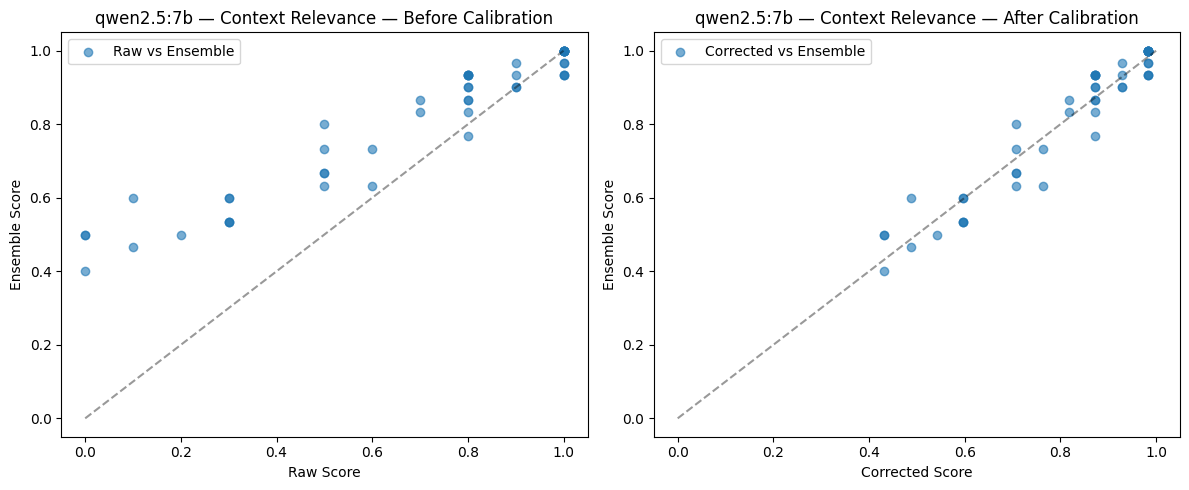

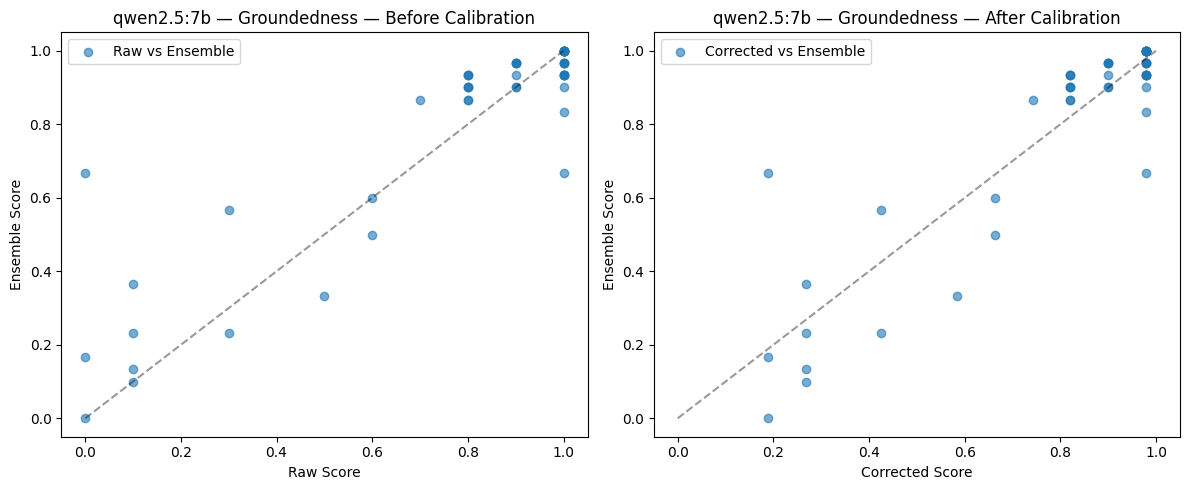

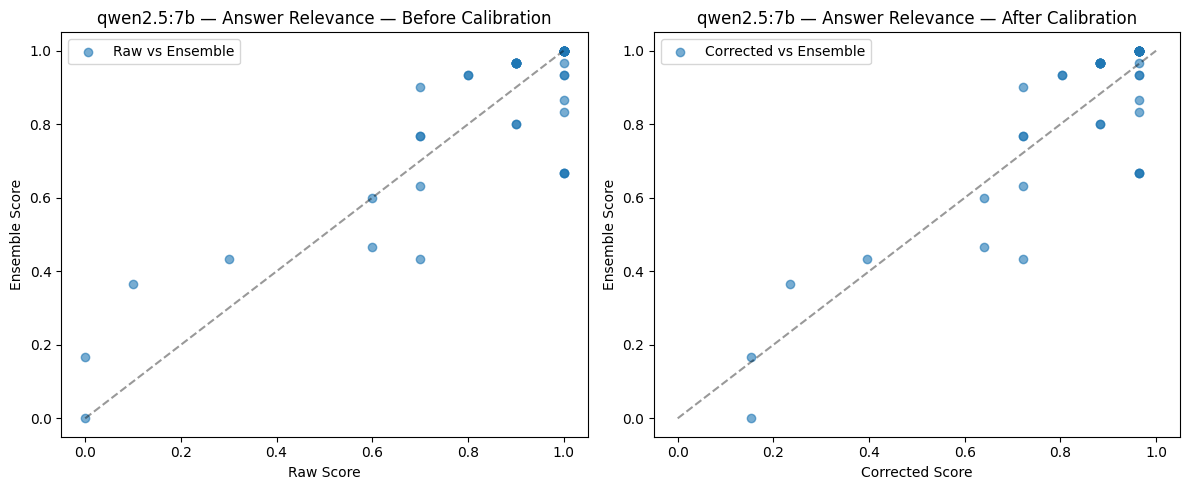

In [5]:
# Calibration curves: raw and corrected vs ensemble
if has_ensemble and fitted_correctors:
    ensemble_scores_dict = scores["ensemble"]

    for model in available_models:
        for metric in METRICS:
            if metric not in scores[model] or metric not in ensemble_scores_dict:
                continue
            if metric not in fitted_correctors.get(model, {}):
                continue
            j = scores[model][metric]
            e = ensemble_scores_dict[metric]
            min_len = min(len(j), len(e))
            j_corr = fitted_correctors[model][metric].transform(j[:min_len])
            fig = calibration_curve(
                raw_scores=j[:min_len],
                corrected_scores=j_corr,
                reference_scores=e[:min_len],
                label=f"{model} — {metric.replace('_', ' ').title()}",
            )
            safe = model.replace(":", "_").replace(".", "_")
            fig.savefig(
                FIGURES_DIR / f"05_calibration_{safe}_{metric}.png", dpi=150, bbox_inches="tight")
            plt.show()
            plt.close(fig)
else:
    print("No calibration data available — run scoring first.")


In [6]:
# Correction table — publishable summary
if not ct_df.empty:
    print("Final correction table (corrected_score = a * raw_score + b):")
    print("=" * 60)
    print(ct_df.sort_values(["model", "metric"]).to_string(index=False))
    print("=" * 60)
    print("\nInterpretation:")
    print("  a > 1 : judge scores are compressed — correction expands the range")
    print("  a < 1 : judge scores are over-dispersed — correction shrinks the range")
    print("  b > 0 : correction shifts scores upward (judge deflates vs ensemble)")
    print("  b < 0 : correction shifts scores downward (judge inflates vs ensemble)")
else:
    print("Correction table not available.")


Final correction table (corrected_score = a * raw_score + b):
      model            metric  a (slope)  b (intercept)
  gemma3:4b  answer_relevance   0.671327       0.259270
  gemma3:4b context_relevance   0.879711       0.038947
  gemma3:4b      groundedness   0.724779       0.193449
llama3.1:8b  answer_relevance   0.493552       0.444890
llama3.1:8b context_relevance   0.704188       0.200098
llama3.1:8b      groundedness   0.813001       0.151648
 qwen2.5:7b  answer_relevance   0.812226       0.152650
 qwen2.5:7b context_relevance   0.551990       0.431564
 qwen2.5:7b      groundedness   0.789339       0.189190

Interpretation:
  a > 1 : judge scores are compressed — correction expands the range
  a < 1 : judge scores are over-dispersed — correction shrinks the range
  b > 0 : correction shifts scores upward (judge deflates vs ensemble)
  b < 0 : correction shifts scores downward (judge inflates vs ensemble)


In [7]:
# Post-calibration kappa summary
if not ba_df.empty:
    print("=" * 65)
    print(f"POST-CALIBRATION KAPPA SUMMARY  (target >= {KAPPA_TARGET})")
    print("=" * 65)
    for model in available_models:
        model_rows = ba_df[ba_df["model"] == model]
        if model_rows.empty:
            continue
        print(f"\n  {model}")
        for _, row in model_rows.iterrows():
            status = "PASS" if row["above_target"] else "FAIL"
            print(f"    {row['metric']:25s}  "
                  f"before={row['kappa_before']:.4f}  "
                  f"after={row['kappa_after']:.4f}  "
                  f"delta={row['delta']:+.4f}  [{status}]")

    n_pass = ba_df["above_target"].sum()
    n_total = len(ba_df)
    print(f"\n  Threshold kappa > {KAPPA_TARGET} reached: {n_pass}/{n_total} (model, metric) pairs")
    print("=" * 65)
else:
    print("No before/after data available.")


POST-CALIBRATION KAPPA SUMMARY  (target >= 0.6)

  gemma3:4b
    context_relevance          before=0.6805  after=0.9042  delta=+0.2237  [PASS]
    groundedness               before=0.7886  after=0.7886  delta=+0.0000  [PASS]
    answer_relevance           before=0.5609  after=0.6212  delta=+0.0604  [PASS]

  llama3.1:8b
    context_relevance          before=0.0775  after=0.1639  delta=+0.0864  [FAIL]
    groundedness               before=0.5935  after=0.5935  delta=+0.0000  [FAIL]
    answer_relevance           before=0.3062  after=0.5930  delta=+0.2868  [FAIL]

  qwen2.5:7b
    context_relevance          before=0.4886  after=0.7452  delta=+0.2566  [PASS]
    groundedness               before=0.8014  after=0.8026  delta=+0.0012  [PASS]
    answer_relevance           before=0.6032  after=0.6032  delta=+0.0000  [PASS]

  Threshold kappa > 0.6 reached: 6/9 (model, metric) pairs


## Conclusion

After linear calibration toward the ensemble consensus, each judge's scores are
closer to the mean of all three judges. The correction table above can be applied
to any evaluation run using these models.

**How to use the correction table in practice:**

1. Run `OllamaJudge.score()` to get raw judge scores.
2. Look up `(model, metric)` in the correction table to retrieve `(a, b)`.
3. Apply `corrected = a * raw + b`, then clip to [0, 1].

The calibrated scores reduce per-judge idiosyncrasies and converge toward
the ensemble mean. Note that calibration toward consensus does not introduce
an external ground truth — it only reduces inter-judge variance.
